In [81]:
import sys
!{sys.executable} -m pip install torch --index-url https://download.pytorch.org/whl/cu121
!{sys.executable} -m pip install kagglehub
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install accelerate


!{sys.executable} -m pip install dotenv
!{sys.executable} -m pip install nltk
!{sys.executable} -m pip install "torch>=2.6" --index-url https://download.pytorch.org/whl/cu124
!{sys.executable} -m pip install numpy scikit-learn transformers matplotlib

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu124



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Outline

Processing Data Options
* remove stop words (words that provide no contextual information on the text). 
    * will not be removing them: tf-idf weights marginalize their ubiquitous presence, and it's possible that a increased density of certain stop words are indicative of various specialties.
* if-idf weighted pooling



1. cosine distance between text embeddings.

Two ways to classify:

a) direct comparison between input embeddings and output embeddings. This is a risky endeavor because it relies on the assumption that there is some innate semantic connection between the embeddings. This may be the case for sinuses and Allergy and Immuniology, but there still are many other medical terms that are often shared by various specialties, and could imply different things (eg discharge:patient discharged vs. discharge of mucus). This is a zero-shot classification via semantic similarity. Technically, a train-test split is unecessary

b) nearest centroid approach: calculate mean of vector embeddings by target value in the training set. For inference, assign the target value with the centroid closest to the test example's text embeddings. Because the centroid's are calculated from the training set, a split is necessasry. If I experiment further, eg in embeddings the vectors via forward pass through BERT model vs. manual computation, then a CV dataset would be necessary as well. 
    
Ways to embed:

a) Word2Vec -> context-free embedings
b) Bert Model, when tokens are processed individually -> context-free embedings (though supposedly the tokens can be retrieved w/o a forward pass)
c) Bert Model, when entire documents are processed -> context affected embeddings, as well as pooled output of the hidden states, which can then be modified for a specific purpose like translation or classification

2. fine-tuned bert. two ways to implement:
    a) frozen-encoder with classification head. the only set of weights to be trained are those in the classification head, a single layer linear classifier appended to the BERT model
    b) non-frozen encode with classification head. not only the classification weights are updated, but the BERT weights are as well. Per claude, there are 110M parameters in the BERT model... so unless I'm OK with waiting hours/days for the training one of one model, this will have to be delayed until I am comfortable outsourcing computation to a cloud-based GPU(s).    
    
Ways to embed:

a) Bert Model, when entire documents are processed -> context affected embeddings, as well as pooled output of the hidden states, which can then be modified for a specific purpose like translation or classification 
   
3. llm
    * no shot
    * few-shot
    
Modules shared by all three:
* The only processes shared by all three are:
    * ingesting and storing dataset in pandas df
    * train-cv-test split
    * 1 and 2: tokening words
    

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import math
from nltk.corpus import stopwords
import torch
from transformers import AutoModel, AutoTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [82]:

from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

### Dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")

In [ ]:
print(os.listdir(path))

['mtsamples.csv']


In [ ]:
file_path = path + '\\' +os.listdir(path)[0]
ds = pd.read_csv(file_path)

In [ ]:
ds = ds[~ds.transcription.isna()]

In [ ]:
unique_specialties_array = ds.medical_specialty.unique()
indexed_distinct_specialties = pd.DataFrame(
    unique_specialties_array,
    columns = ['medical_specialty'],
    index = range(len(unique_specialties_array))
).reset_index(drop=False).rename(columns = {'index':'specialty_index'})

In [ ]:
ds = ds.merge(indexed_distinct_specialties, on = 'medical_specialty')

In [ ]:
ds.transcription

0       SUBJECTIVE:,  This 23-year-old white female pr...
1       PAST MEDICAL HISTORY:, He has difficulty climb...
2       HISTORY OF PRESENT ILLNESS: , I have seen ABC ...
3       2-D M-MODE: , ,1.  Left atrial enlargement wit...
4       1.  The left ventricular cavity size and wall ...
                              ...                        
4961    HISTORY:,  I had the pleasure of meeting and e...
4962    ADMITTING DIAGNOSIS: , Kawasaki disease.,DISCH...
4963    SUBJECTIVE: , This is a 42-year-old white fema...
4964    CHIEF COMPLAINT: , This 5-year-old male presen...
4965    HISTORY: , A 34-year-old male presents today s...
Name: transcription, Length: 4966, dtype: str

### Transcription Length

* the bert model has input token limit of 512, so I first explore the lengths of the transcriptions
* most transcriptions likely will have more than 512 tokens, so I'll need to truncate before feeding the entire tokenized string to the model.

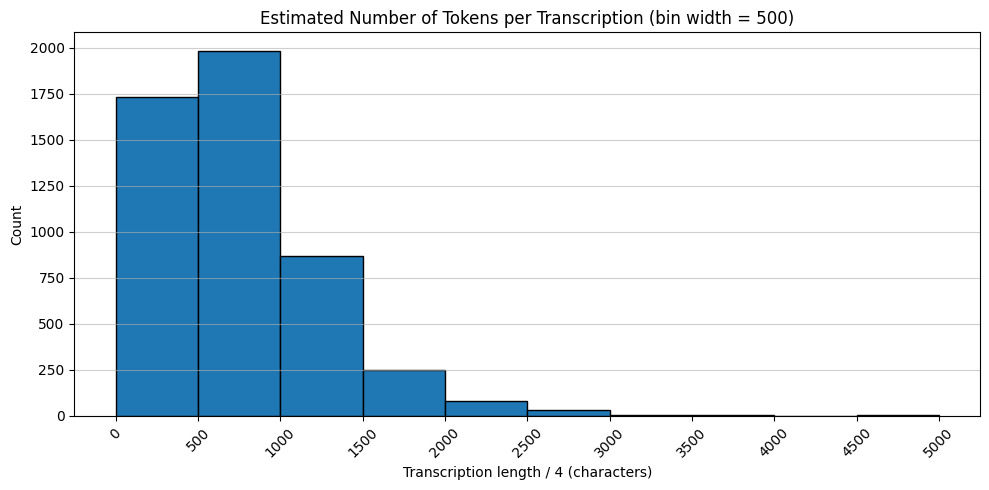

In [ ]:
# Histogram of transcription lengths divided by 4, with bin width of 500
lengths_div4 = ds.transcription.str.len() / 4
lengths = lengths_div4.dropna()

bin_width = 500
start = np.floor(lengths.min() / bin_width) * bin_width
end = np.ceil(lengths.max() / bin_width) * bin_width
bins = np.arange(start, end + bin_width, bin_width)

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=bins, edgecolor='black')
plt.xlabel('Transcription length / 4 (characters)')
plt.ylabel('Count')
plt.title(f'Estimated Number of Tokens per Transcription (bin width = {bin_width})')
plt.grid(axis='y', alpha=0.6)
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

### Tokenize and Embed Transcriptions

* Use a medically-related tokenizer that either recognizes medical terminology, or breaks up unknown words into subwords, or morphemes, often present in the lexicon.

In [ ]:
class corpus_encoder():
    
    def __init__(
        self, 
        corpus:list, 
        tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT"),
        # default would be AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
        # if loading the model didn't take several minutes, a waste for applications that only require tokenization
        model = None
    ):
        self.raw_corpus = corpus
        self.tokenizer = tokenizer
        self.token_embeddings = {}
        self.tokenized_corpus = []
        self.token_idfs = {}
        self.model = model
        self.pooled_emb = []
    
    def tokenize_corpus(self, corpus = None):
        '''
        input: None
        output: list of lists
        tokenize the entire corpus doc by doc
        the returned list, also stored in object, is in same order of the raw corpus
        '''
        passed = True

        # make local copies of the corpus because I don't want
        # to alter the reference
        if corpus is None:
            corpus = self.raw_corpus[:]
            passed = False

        else:
            corpus = corpus[:]

        # "resource is not available"
        # stop_words = set(stopwords.words('english'))
        stop_words = [
            ' the ',' a ',' an ',' I ', ' you ', ' he ',
            ' A ',' The ', ' she ', ' me ',' my ', ' their ',
            ' has ', ' had ', ' have ', ' be ', ' is ', ' was ',
            ' were ', ' not ', ' they '
        ]
        
        tokenized_corpus = []
        
        for doc in corpus:
            
            for word in stop_words:
                doc.replace(word, ' ')
            tokenized_corpus.append(
                self.tokenizer.encode(doc, add_special_tokens=False)
            )

        if not passed:
            self.tokenized_corpus = tokenized_corpus

        return tokenized_corpus
            
    def __tf_idf_embed_document__(self, document):
        '''
        input: 
            document: list of integers
        output:
            weighted_avg_embedding: pytorch tensor of average doc embeddings 
                weighted by tf-idf scores
        
        '''
        
        # calculate tf scores
        token_tf_scores = {}
        
        for token in document:
            token_tf_scores[token] = token_tf_scores.setdefault(token, 0) + 1 / len(document)
            
        weighted_avg_embedding = None
        
        for token, tf_score in token_tf_scores.items():

            try:
               token_idf = self.token_idfs[token]
            except:
                # token was not in object corpus
                continue
            
            try:
                # if already embedded, retrieve vector
                raw_embedding = self.token_embeddings[token]
            
            except: 
                raw_embedding = self.model.embeddings.word_embeddings(torch.tensor([token]))
                self.token_embeddings[token] = raw_embedding
            
            token_weighted_embedding = (
                raw_embedding * tf_score * token_idf
            )
                
            if weighted_avg_embedding is not None:
                weighted_avg_embedding += token_weighted_embedding
            else:
                weighted_avg_embedding = token_weighted_embedding

        if weighted_avg_embedding is None:
            weighted_avg_embedding = torch.zeros(
                1, next(self.model.parameters()).shape[-1]
            )
        
        return weighted_avg_embedding
        
    def model_embed_corpus(self, corpus = None):
        '''
        input:
            [list] corpus: (optional) corpus other than object's for embedding on model 
        output:
            [tensor] shape [N, 768]: embeddings of docs, in same order as passed list
        '''
        
        if corpus is None:
            corpus = self.raw_corpus
        
        model_emb = []
        
        for doc in corpus:

            inputs = self.tokenizer(doc, return_tensors="pt", truncation=True, padding=True, max_length=512)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                output = self.model(**inputs)

            # CLS token — the first token, often used as a document-level embedding
            embedding = output.last_hidden_state[:, 0, :]  # shape: [1, 768]

            model_emb.append(embedding)
    
        return torch.cat(model_emb, dim=0)

    
    def pool_embed_corpus(self, corpus = None):
        """
        input:
            [list] corpus: (optional) corpus other than object's for embedding using object's idf scores 
        output:
            [list] pooled_emb: list of pytorch vectors corresponding to doc in corpus
        """
        
        if len(self.tokenized_corpus) == 0:
            self.tokenize_corpus()
        
        if len(self.token_idfs) == 0:
            self.__calculate_idf__()

        if corpus is not None:
            tokenized_corpus = self.tokenize_corpus(corpus)
        else:
            tokenized_corpus = self.tokenized_corpus

        pooled_emb = []
        
        for doc in tokenized_corpus:
            pooled_emb.append(self.__tf_idf_embed_document__(doc))

        if corpus is None:
            self.pooled_emb = pooled_emb

        return pooled_emb

        
    def __calculate_idf__(self):
        """
        input: NA
        output: NA

        Calculates idf scores of the corpus
        """

        token_frequency = {}
        
        for doc in self.tokenized_corpus:
            
            for token in set(doc):
                token_frequency[token] = token_frequency.setdefault(token, 0) + 1
                
        self.token_idfs = {}
        num_docs = len(self.tokenized_corpus)
        
        for token, frequency in token_frequency.items():
            self.token_idfs[token] = math.log(num_docs / frequency,10)

### Tokenize and Embed

* The embedding method that needs to split the data into train-test prior, is the tf-idf due to the possibility of target leakage in creating idf scores.

In [ ]:
# train, cv, test split before 
_transcription_train, transc_test, _specialty_index_train, specialty_index_test = train_test_split(
    ds.transcription, ds.specialty_index, 
    test_size=0.2,          # 20% for testing, 80% for training+cv
    stratify=ds['specialty_index'], # Preserves 'group_col' proportions in train and test
    random_state=42         # Ensures reproducibility
)

transc_train, transc_cv, specialty_index_train, specialty_index_cv = train_test_split(
    _transcription_train, _specialty_index_train, 
    test_size=0.25,          # 20% for cv, 60% for training
    stratify=_specialty_index_train, # Preserves 'group_col' proportions in train and test
    random_state=42         # Ensures reproducibility
)

specialty_index_train = torch.tensor(specialty_index_train.values, dtype=torch.long)
specialty_index_cv = torch.tensor(specialty_index_cv.values, dtype=torch.long)
specialty_index_test = torch.tensor(specialty_index_test.values, dtype=torch.long)

##### TF-IDF POOLED EMBEDDINGS

In [ ]:
transc_train_enc_tf_idf = corpus_encoder(
    corpus = transc_train.to_list(),
    model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT").to(device)
)
transc_train_enc_tf_idf.tokenize_corpus()

transc_train_emb_tf_idf = transc_train_enc_tf_idf.pool_embed_corpus()
transc_test_emb_tf_idf = transc_train_enc_tf_idf.pool_embed_corpus(transc_test)

distinct_specialty_emb_tf_idf = transc_train_enc_tf_idf.pool_embed_corpus(indexed_distinct_specialties.medical_specialty)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2384.99it/s]
[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

transc_test_emb_matrix_tf_idf = torch.stack(
    [i.view(-1) for i in transc_test_emb_tf_idf]
)

transc_train_emb_matrix_tf_idf = torch.stack(
    [i.view(-1) for i in transc_train_emb_tf_idf]
)

distinct_specialty_emb_matrix_tf_idf = torch.stack(
    [i.view(-1) for i in distinct_specialty_emb_tf_idf]
)

##### Contextual Embedding

In [ ]:
# splitting into train/test is not necessary: contextual embeddings
# are outputted from pre-trained, frozen BERT model.

transc_enc_cntxt = corpus_encoder(
    corpus = transc_train.to_list(),
    model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT").to(device)
)

transc_enc_cntxt.tokenize_corpus()
transc_train_emb_cntxt = transc_train_enc_tf_idf.model_embed_corpus()
specialty_embeddings_contextual = transc_enc_cntxt.model_embed_corpus(indexed_distinct_specialties.medical_specialty)

transc_test_emb_cntxt = transc_train_enc_tf_idf.model_embed_corpus(transc_test)
transc_cv_emb_cntxt = transc_train_enc_tf_idf.model_embed_corpus(transc_cv)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 663.04it/s]
[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
transc_test_emb_matrix_cntxt = transc_test_emb_cntxt.to(device)

# cv to not be used here, but in later methods
transc_cv_emb_matrix_cntxt = transc_cv_emb_cntxt.to(device)

transc_train_emb_matrix_cntxt = transc_train_emb_cntxt.to(device)

distinct_specialty_emb_matrix_cntxt = specialty_embeddings_contextual.to(device)

### Classify with Cosine Distance

In [ ]:
from sklearn.metrics import classification_report

class cosine_distance_classification():

    def __init__(
        self,
        test_actual_values: list,
        test_input_embeddings: torch.tensor,
        distinct_output_emb: torch.tensor
    ):
        '''
        actual_values (list): actual values, in same order as input embeddings,
            represented by output index reflected in distinct_output_emb
        input_emb (tensor): tensor with shape (num_train, len_embeddings)
        distinct_output_emb (tensor): tensor with shape (num_distinct_specialties, len_embeddings)
        '''

        self.test_actual_outputs = test_actual_values
        self.test_input_embeddings = test_input_embeddings
        self.distinct_output_emb = distinct_output_emb

    def classify(self):
        # calculate dot product of each input and output, 
        # resulting in matrix of dimensions [num_train, num_distinct_specialties]
        cosine_distance_matrix = self.test_input_embeddings @ self.distinct_output_emb.T
        # divide each column by magnitudes of input embeddings 
        cosine_distance_matrix = cosine_distance_matrix / torch.linalg.norm(self.test_input_embeddings,dim=1)[:,None]
        # divide each row by magnitudes of output embeding
        cosine_distance_matrix = cosine_distance_matrix / torch.linalg.norm(self.distinct_output_emb,dim=1)
        # complete formula of cosine distance
        cosine_distance_matrix = 1 - cosine_distance_matrix

        # select the closest
        self.output_prediction_indices = torch.argmin(cosine_distance_matrix, -1)

    def print_accuracy(self):
        
        report_dict = classification_report(
            self.test_actual_outputs, 
            self.output_prediction_indices.view(-1).tolist(),
            output_dict=True
        )

        # Convert dictionary to a Pandas DataFrame and transpose for table layout
        metrics_table = pd.DataFrame(report_dict).transpose()

        # Clean up the table for presentation (rounding to 3 decimals)
        metrics_table = metrics_table.round(3)

        # Display the resulting table
        print(metrics_table)




##### Using Pooled Embeddings

In [ ]:
cosine_tf_idf_classifier = cosine_distance_classification(
    test_actual_values = specialty_index_test.tolist(),
    test_input_embeddings = transc_test_emb_matrix_tf_idf,
    distinct_output_emb = distinct_specialty_emb_matrix_tf_idf,
)

In [ ]:
cosine_tf_idf_classifier.classify()

In [ ]:
cosine_tf_idf_classifier.print_accuracy()

              precision  recall  f1-score  support
0                 0.000   0.000     0.000    1.000
1                 0.000   0.000     0.000    4.000
2                 0.000   0.000     0.000   74.000
3                 0.000   0.000     0.000   45.000
4                 0.000   0.000     0.000    5.000
5                 0.000   0.000     0.000   31.000
6                 0.000   0.000     0.000   52.000
7                 0.000   0.000     0.000  218.000
8                 0.000   0.000     0.000    2.000
9                 0.000   0.000     0.000   33.000
10                0.000   0.000     0.000    4.000
11                0.000   0.000     0.000    2.000
12                0.000   0.000     0.000   55.000
13                0.000   0.000     0.000   11.000
14                0.000   0.000     0.000    9.000
15                0.000   0.000     0.000    4.000
16                0.000   0.000     0.000   14.000
17                0.000   0.000     0.000   12.000
18                0.000   0.000

c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

##### Using Contextual Embeddings

In [ ]:
cosine_tf_idf_classifier = cosine_distance_classification(
    test_actual_values = specialty_index_test.tolist(),
    test_input_embeddings = transc_test_emb_matrix_cntxt,
    distinct_output_emb = distinct_specialty_emb_matrix_cntxt,
)

In [ ]:
cosine_tf_idf_classifier.classify()

In [ ]:
cosine_tf_idf_classifier.print_accuracy()

              precision  recall  f1-score  support
0                 0.000   0.000     0.000    1.000
1                 0.000   0.000     0.000    4.000
2                 0.000   0.000     0.000   74.000
3                 0.000   0.000     0.000   45.000
4                 0.000   0.000     0.000    5.000
5                 0.000   0.000     0.000   31.000
6                 0.000   0.000     0.000   52.000
7                 0.000   0.000     0.000  218.000
8                 0.000   0.000     0.000    2.000
9                 0.000   0.000     0.000   33.000
10                0.000   0.000     0.000    4.000
11                0.000   0.000     0.000    2.000
12                0.250   0.036     0.063   55.000
13                0.000   0.000     0.000   11.000
14                0.000   0.000     0.000    9.000
15                0.042   0.250     0.071    4.000
16                0.041   0.143     0.063   14.000
17                0.000   0.000     0.000   12.000
18                0.000   0.000

c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Classify with Closest Centroid

In [ ]:
class closest_centroid_classifier():
    from sklearn.metrics import classification_report

    def __init__(
        self,
        train_input_embeddings: torch.tensor,
        train_output_values: list,
        test_output_values: list,
        test_input_embeddings: torch.tensor,
    ):
        self.train_input_embeddings = train_input_embeddings
        # assumes train_y is ordinal
        self.train_output_values = train_output_values
        self.test_output_values = test_output_values
        self.test_input_embeddings = test_input_embeddings

    def classify(self):
        # avg vector from test
        target_value_centroids = torch.zeros(
            len(set(self.train_output_values)), self.train_input_embeddings.shape[1]
        ).to(device)
        
        target_value_counts = {value: 0 for value in set(self.train_output_values)}

        for torch_vector, target_value in zip(self.train_input_embeddings, self.train_output_values):
            target_value_centroids[target_value] += torch_vector.view(-1)

            target_value_counts[target_value] += 1

        for target_value, count in target_value_counts.items():

            target_value_centroids[target_value] = target_value_centroids[target_value] / count

        # create dot product between every test record and target value
        cosine_distance_matrix = self.test_input_embeddings @ target_value_centroids.T

        # divide each column by magnitudes of transcription embeding
        cosine_distance_matrix = cosine_distance_matrix / torch.linalg.norm(self.test_input_embeddings,dim=1)[:,None]
        # divide each row by magnitudes of specialty embeding
        cosine_distance_matrix = cosine_distance_matrix / torch.linalg.norm(target_value_centroids,dim=1)
        # complete formula of cosine distance
        cosine_distance_matrix = 1 - cosine_distance_matrix

        self.target_prediction_indices = torch.argmin(cosine_distance_matrix, -1)

    def print_accuracy(self):
        report_dict = classification_report(
            self.test_output_values, 
            self.target_prediction_indices.view(-1).tolist(),
            output_dict=True
        )

        # Convert dictionary to a Pandas DataFrame and transpose for table layout
        metrics_table = pd.DataFrame(report_dict).transpose()

        # Clean up the table for presentation (rounding to 3 decimals)
        metrics_table = metrics_table.round(3)

        # Display the resulting table
        print(metrics_table)

##### TF-IDF Pooled Embeddings

In [ ]:
ccc = closest_centroid_classifier(
    train_input_embeddings = transc_train_emb_matrix_tf_idf,
    train_output_values = specialty_index_train.tolist(),
    test_output_values = specialty_index_test.tolist(),
    test_input_embeddings = transc_test_emb_matrix_tf_idf
)

In [ ]:
ccc.classify()

In [ ]:
ccc.print_accuracy()

              precision  recall  f1-score  support
0                 0.250   1.000     0.400     1.00
1                 0.375   0.750     0.500     4.00
2                 0.510   0.338     0.407    74.00
3                 0.378   0.378     0.378    45.00
4                 0.455   1.000     0.625     5.00
5                 0.423   0.355     0.386    31.00
6                 0.208   0.192     0.200    52.00
7                 0.509   0.261     0.345   218.00
8                 0.333   0.500     0.400     2.00
9                 0.312   0.455     0.370    33.00
10                0.400   1.000     0.571     4.00
11                0.000   0.000     0.000     2.00
12                0.472   0.309     0.374    55.00
13                0.280   0.636     0.389    11.00
14                0.353   0.667     0.462     9.00
15                0.300   0.750     0.429     4.00
16                0.308   0.286     0.296    14.00
17                0.571   0.667     0.615    12.00
18                0.543   0.535

##### Using Contextual Embeddings

In [ ]:
ccc = closest_centroid_classifier(
    train_input_embeddings = transc_train_emb_matrix_cntxt,
    train_output_values = specialty_index_train.tolist(),
    test_output_values = specialty_index_test.tolist(),
    test_input_embeddings = transc_test_emb_matrix_cntxt
)

In [ ]:
ccc.classify()

In [ ]:
ccc.print_accuracy()

              precision  recall  f1-score  support
0                 0.000   0.000     0.000    1.000
1                 0.250   0.250     0.250    4.000
2                 0.368   0.095     0.151   74.000
3                 0.556   0.222     0.317   45.000
4                 0.333   0.400     0.364    5.000
5                 0.500   0.129     0.205   31.000
6                 0.045   0.019     0.027   52.000
7                 0.493   0.486     0.490  218.000
8                 0.500   0.500     0.500    2.000
9                 0.200   0.242     0.219   33.000
10                0.250   1.000     0.400    4.000
11                0.200   0.500     0.286    2.000
12                0.391   0.491     0.435   55.000
13                0.217   0.455     0.294   11.000
14                0.200   0.111     0.143    9.000
15                0.200   0.750     0.316    4.000
16                0.167   0.071     0.100   14.000
17                0.180   0.750     0.290   12.000
18                0.368   0.099

### Classify with Frozen Encoder BERT Model

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

torch.manual_seed(123)

In [ ]:
class Dataset_Eso(Dataset):

    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y
    
    def __len__(self):
        return self.labels.shape[0]

In [ ]:

train_ds = Dataset_Eso(transc_train_emb_matrix_cntxt, specialty_index_train)
cv_ds = Dataset_Eso(transc_cv_emb_matrix_cntxt, specialty_index_cv)
test_ds = Dataset_Eso(transc_test_emb_matrix_cntxt, specialty_index_test)

In [ ]:
#
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs, hidden_layer):
        super().__init__()

        self.layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_inputs, hidden_layer),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(hidden_layer, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

In [68]:
class frozen_BERT_classifier():
    from sklearn.metrics import classification_report

    def __init__(
        self,
        train_ds: Dataset_Eso,
        cv_ds: Dataset_Eso,
        test_ds: Dataset_Eso,

    ):
        
        self.train_ds = train_ds
        self.cv_ds = cv_ds
        self.test_ds = test_ds

        self.train_dl = DataLoader(
            dataset = train_ds,
            batch_size = 32,
            shuffle= True,
            num_workers = 0,
            generator = torch.Generator(device=device)
        )

        self.tested_model_results = {}

        self.default_model = None

    def grid_search(self, learning_rates:list, hidden_nodes:list):
        '''
        perform grid search to pinpoint best values for learning rate and nodes of hidden layer
        '''

        for learning_rate in learning_rates:
            for nodes in hidden_nodes:

                model = self.train_model(lr = learning_rate, nodes = nodes)

                results = self.assess_model_accuracy(model, on_cv = True)

                self.tested_model_results[(learning_rate, nodes)] = (model, results)


    def train_model(self, lr, nodes):
        '''
        given defined parameters of learning rate and hidden layer nodes,
        create and train a classifier model
        '''
    
        model = NeuralNetwork(
            num_inputs = self.train_ds.features.shape[1], 
            num_outputs = self.train_ds.labels.max() + 1,
            hidden_layer = nodes
        ).to(device)
    
        optimizer = torch.optim.SGD(
            model.parameters(), lr = lr
        )

        prev_loss = 10**8
        epoch_cv_loss = 10**7
    
        while (epoch_cv_loss - prev_loss) / prev_loss < -0.001:

            prev_loss = epoch_cv_loss

            model.train()
            for features, labels in self.train_dl:

                logits = model(features)
                batch_loss = F.cross_entropy(logits, labels)  # Loss function

                optimizer.zero_grad()
                batch_loss.backward()
                optimizer.step()

            with torch.no_grad():
                logits = model(self.cv_ds.features)
                epoch_cv_loss = F.cross_entropy(logits, self.cv_ds.labels)  # Loss function
        
        return model

    def set_model(self, params:tuple):
        '''
        select from the grid search a specific model to set as the object's
        '''
        self.default_model = self.tested_model_results[params][0]


    def assess_model_accuracy(self, model, on_cv):
        '''
        assess accuracy of model on either cv or test dataset
        '''
        if on_cv:
            X = self.cv_ds.features
            y = self.cv_ds.labels
        else:
            X = self.test_ds.features
            y = self.test_ds.labels
        with torch.no_grad():
            logits = model(X).to(device)
        
        predictions = torch.argmax(logits, dim=1)

        return torch.sum(predictions == y) / predictions.shape[0]
    
    def print_grid_search_results(self):
        '''
        visualize accuracy of the tested models
        '''
        learning_rates = sorted(set(lr for lr, _ in self.tested_model_results))
        nodes_list = sorted(set(nodes for _, nodes in self.tested_model_results))

        accuracy_matrix = np.zeros((len(learning_rates), len(nodes_list)))

        for (lr, nodes), (model, accuracy) in self.tested_model_results.items():
            row = learning_rates.index(lr)
            col = nodes_list.index(nodes)
            accuracy_matrix[row, col] = accuracy

        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(accuracy_matrix, cmap='YlGn', aspect='auto',
                       vmin=0, vmax=1)

        ax.set_xticks(range(len(nodes_list)))
        ax.set_xticklabels(nodes_list)
        ax.set_yticks(range(len(learning_rates)))
        ax.set_yticklabels(learning_rates)

        ax.set_xlabel('Hidden Nodes')
        ax.set_ylabel('Learning Rate')
        ax.set_title('Grid Search CV Accuracy')

        for i in range(len(learning_rates)):
            for j in range(len(nodes_list)):
                ax.text(j, i, f'{accuracy_matrix[i, j]:.3f}',
                        ha='center', va='center', fontsize=10)

        plt.colorbar(im, ax=ax, label='Accuracy')
        plt.tight_layout()
        plt.show()

    def test_and_print_accuracy(self):
        '''
        test the model on the test dataset,
        outputting precision 
        '''

        with torch.no_grad():
            logits = self.default_model(self.test_ds.features)
        
        predictions = torch.argmax(logits, dim=1)

        report_dict = classification_report(
            self.test_ds.labels.view(-1).tolist(), 
            predictions.view(-1).tolist(),
            output_dict=True
        )

        # Convert dictionary to a Pandas DataFrame and transpose for table layout
        metrics_table = pd.DataFrame(report_dict).transpose()

        # Clean up the table for presentation (rounding to 3 decimals)
        metrics_table = metrics_table.round(3)

        # Display the resulting table
        print(metrics_table)

In [69]:
fbc = frozen_BERT_classifier(
    train_ds = train_ds,
    cv_ds = cv_ds,
    test_ds = test_ds, 
)

In [ ]:
fbc.grid_search(
    learning_rates =[0.0003, 0.001, 0.003,0.01, 0.03],
    hidden_nodes = [50, 100, 150, 200, 300]
)


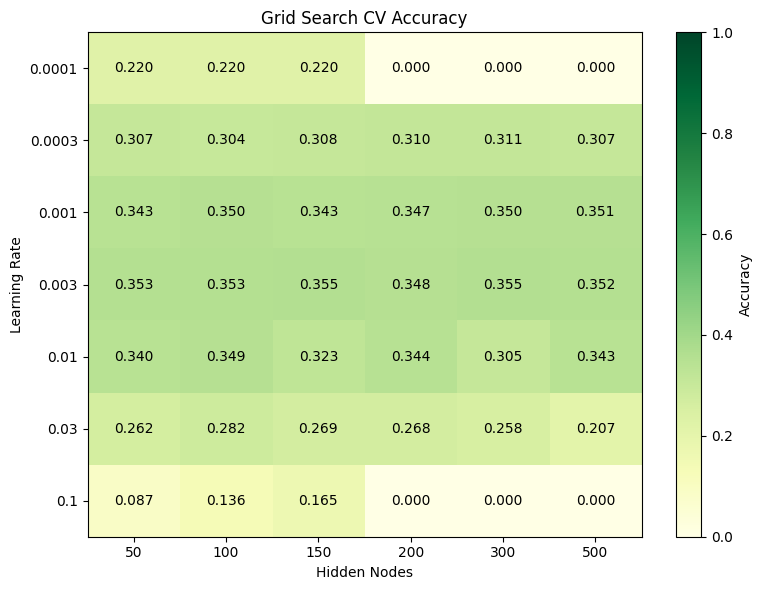

In [77]:
fbc.print_grid_search_results()

In [78]:
fbc.set_model(params = (0.003,50))

In [79]:
fbc.test_and_print_accuracy()

              precision  recall  f1-score  support
0                 0.000   0.000     0.000    1.000
1                 0.000   0.000     0.000    4.000
2                 0.435   0.135     0.206   74.000
3                 0.222   0.044     0.074   45.000
4                 0.000   0.000     0.000    5.000
5                 0.000   0.000     0.000   31.000
6                 0.000   0.000     0.000   52.000
7                 0.431   0.995     0.601  218.000
8                 0.000   0.000     0.000    2.000
9                 0.000   0.000     0.000   33.000
10                0.000   0.000     0.000    4.000
11                0.000   0.000     0.000    2.000
12                0.337   0.509     0.406   55.000
13                0.000   0.000     0.000   11.000
14                0.000   0.000     0.000    9.000
15                0.000   0.000     0.000    4.000
16                0.000   0.000     0.000   14.000
17                0.000   0.000     0.000   12.000
18                0.500   0.028

c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\16099\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Classify with Claude Code

Did my efforts outperform the readily-available foundational model?

In [86]:
import sys
!{sys.executable} -m pip install anthropic

import anthropic

  Obtaining dependency information for anthropic from https://files.pythonhosted.org/packages/83/75/be0c357e33a5a56c8f9db5b4212f886138d2bf59c0952d858f6b75d710ef/anthropic-0.105.2-py3-none-any.whl.metadata
  Obtaining dependency information for distro<2,>=1.7.0 from https://files.pythonhosted.org/packages/12/b3/231ffd4ab1fc9d679809f356cebee130ac7daa00d6d6f3206dd4fd137e9e/distro-1.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for docstring-parser<1,>=0.15 from https://files.pythonhosted.org/packages/a7/5f/ed01f9a3cdffbd5a008556fc7b2a08ddb1cc6ace7effa7340604b1d16699/docstring_parser-0.18.0-py3-none-any.whl.metadata
  Obtaining dependency information for jiter<1,>=0.4.0 from https://files.pythonhosted.org/packages/95/bf/8ead82a87495149542748e828d153fd232a512a22c83b02c4815c1a9c7d8/jiter-0.15.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for pydantic<3,>=1.9.0 from https://files.pythonhosted.org/packages/fd/7b/122376b1fd3c62c1ed9dc80c931ace4844b3c


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
class claude_zero_shot_classifier():

    def __init__(
        self,
        test_transcriptions,
        test_actual_values,
        specialty_names,
        model: str = "claude-opus-4-7",
        max_samples: int = 50
    ):
        self.test_transcriptions = test_transcriptions
        self.test_actual_values = test_actual_values
        self.specialty_names = specialty_names
        self.model = model
        self.max_samples = max_samples
        self.predictions = []
        self.actual_used = []
        self.client = anthropic.Anthropic()

    def _parse_prediction(self, raw: str) -> int:
        raw = raw.strip()
        if raw in self.specialty_names:
            return self.specialty_names.index(raw)
        raw_lower = raw.lower()
        for i, name in enumerate(self.specialty_names):
            if name.strip().lower() == raw_lower:
                return i
        return -1

    def classify(self):
        specialty_list = "\n".join(f"- {s}" for s in self.specialty_names)
        system_text = (
            "You are a medical specialty classifier. "
            "Given a medical transcription, classify it into exactly one of the following specialties:\n\n"
            f"{specialty_list}\n\n"
            "Respond with only the specialty name, exactly as written above. No other text."
        )

        transcriptions = self.test_transcriptions
        actual = self.test_actual_values
        if self.max_samples is not None:
            transcriptions = transcriptions[:self.max_samples]
            actual = actual[:self.max_samples]

        self.predictions = []
        self.actual_used = list(actual)

        for transcription in transcriptions:
            response = self.client.messages.create(
                model=self.model,
                max_tokens=64,
                system=[{
                    "type": "text",
                    "text": system_text,
                    "cache_control": {"type": "ephemeral"}
                }],
                messages=[{"role": "user", "content": str(transcription)[:4000]}]
            )
            predicted_idx = self._parse_prediction(response.content[0].text)
            self.predictions.append(predicted_idx)

    def print_accuracy(self):
        valid = [(a, p) for a, p in zip(self.actual_used, self.predictions) if p != -1]
        if not valid:
            print("No valid predictions.")
            return
        actuals, preds = zip(*valid)
        report_dict = classification_report(actuals, preds, output_dict=True, zero_division=0)
        metrics_table = pd.DataFrame(report_dict).transpose().round(3)
        print(f"Valid predictions: {len(valid)} / {len(self.predictions)}")
        print(metrics_table)

In [88]:
class claude_few_shot_classifier():

    def __init__(
        self,
        train_transcriptions,
        train_actual_values,
        test_transcriptions,
        test_actual_values,
        specialty_names,
        n_examples_per_class: int = 2,
        model: str = "claude-opus-4-7",
        max_samples: int = 50
    ):
        self.train_transcriptions = train_transcriptions
        self.train_actual_values = train_actual_values
        self.test_transcriptions = test_transcriptions
        self.test_actual_values = test_actual_values
        self.specialty_names = specialty_names
        self.n_examples = n_examples_per_class
        self.model = model
        self.max_samples = max_samples
        self.predictions = []
        self.actual_used = []
        self.client = anthropic.Anthropic()

    def _build_examples_block(self) -> str:
        from collections import defaultdict
        by_class = defaultdict(list)
        for text, label in zip(self.train_transcriptions, self.train_actual_values):
            by_class[int(label)].append(str(text)[:800])
        lines = []
        for idx, name in enumerate(self.specialty_names):
            for ex in by_class.get(idx, [])[:self.n_examples]:
                lines.append(f"Specialty: {name}\nTranscription: {ex}\n")
        return "\n".join(lines)

    def _parse_prediction(self, raw: str) -> int:
        raw = raw.strip()
        if raw in self.specialty_names:
            return self.specialty_names.index(raw)
        raw_lower = raw.lower()
        for i, name in enumerate(self.specialty_names):
            if name.strip().lower() == raw_lower:
                return i
        return -1

    def classify(self):
        specialty_list = "\n".join(f"- {s}" for s in self.specialty_names)
        examples_block = self._build_examples_block()
        system_text = (
            "You are a medical specialty classifier. "
            "Classify the given transcription into exactly one of the following specialties:\n\n"
            f"{specialty_list}\n\n"
            "Here are labeled examples to guide you:\n\n"
            f"{examples_block}\n"
            "Respond with only the specialty name, exactly as written above. No other text."
        )

        transcriptions = self.test_transcriptions
        actual = self.test_actual_values
        if self.max_samples is not None:
            transcriptions = transcriptions[:self.max_samples]
            actual = actual[:self.max_samples]

        self.predictions = []
        self.actual_used = list(actual)

        for transcription in transcriptions:
            response = self.client.messages.create(
                model=self.model,
                max_tokens=64,
                system=[{
                    "type": "text",
                    "text": system_text,
                    "cache_control": {"type": "ephemeral"}
                }],
                messages=[{"role": "user", "content": str(transcription)[:4000]}]
            )
            predicted_idx = self._parse_prediction(response.content[0].text)
            self.predictions.append(predicted_idx)

    def print_accuracy(self):
        valid = [(a, p) for a, p in zip(self.actual_used, self.predictions) if p != -1]
        if not valid:
            print("No valid predictions.")
            return
        actuals, preds = zip(*valid)
        report_dict = classification_report(actuals, preds, output_dict=True, zero_division=0)
        metrics_table = pd.DataFrame(report_dict).transpose().round(3)
        print(f"Valid predictions: {len(valid)} / {len(self.predictions)}")
        print(metrics_table)

In [91]:
specialty_names = indexed_distinct_specialties.sort_values('specialty_index')['medical_specialty'].tolist()

zs = claude_zero_shot_classifier(
    test_transcriptions=transc_test.tolist(),
    test_actual_values=specialty_index_test.tolist(),
    specialty_names=specialty_names,
    max_samples=500
)
zs.classify()
zs.print_accuracy()

Valid predictions: 500 / 500
              precision  recall  f1-score  support
0                 1.000   1.000     1.000    1.000
1                 0.600   0.750     0.667    4.000
2                 0.538   0.700     0.609   40.000
3                 0.467   0.333     0.389   21.000
4                 0.500   1.000     0.667    2.000
5                 0.350   0.500     0.412   14.000
6                 0.250   0.250     0.250   24.000
7                 0.486   0.333     0.395  102.000
8                 1.000   1.000     1.000    1.000
9                 0.389   0.438     0.412   16.000
10                0.667   1.000     0.800    2.000
11                0.500   1.000     0.667    2.000
12                0.444   0.571     0.500   35.000
13                0.250   0.500     0.333    4.000
14                0.500   1.000     0.667    4.000
15                1.000   0.500     0.667    2.000
16                0.400   0.222     0.286    9.000
17                0.800   1.000     0.889    4.000
18

In [92]:
fs = claude_few_shot_classifier(
    train_transcriptions=transc_train.tolist(),
    train_actual_values=specialty_index_train.tolist(),
    test_transcriptions=transc_test.tolist(),
    test_actual_values=specialty_index_test.tolist(),
    specialty_names=specialty_names,
    n_examples_per_class=2,
    max_samples=500
)
fs.classify()
fs.print_accuracy()

Valid predictions: 490 / 500
              precision  recall  f1-score  support
0                 0.500   1.000     0.667    1.000
1                 0.750   0.750     0.750    4.000
2                 0.538   0.700     0.609   40.000
3                 0.469   0.714     0.566   21.000
4                 0.500   1.000     0.667    2.000
5                 0.278   0.385     0.323   13.000
6                 0.227   0.217     0.222   23.000
7                 0.451   0.232     0.307   99.000
8                 1.000   1.000     1.000    1.000
9                 0.500   0.125     0.200   16.000
10                0.667   1.000     0.800    2.000
11                0.400   1.000     0.571    2.000
12                0.500   0.571     0.533   35.000
13                0.375   0.750     0.500    4.000
14                0.500   1.000     0.667    3.000
15                0.500   0.500     0.500    2.000
16                0.375   0.429     0.400    7.000
17                0.500   1.000     0.667    4.000
18